1. Фрагмент исходного набора данных:
Размерность данных: (506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM    AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575   65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421   78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185   61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998   45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147   54.2  6.0622    3  222.0   
5  0.02985   0.0   2.18     0  0.458  6.430   58.7  6.0622    3  222.0   
6  0.08829  12.5   7.87     0  0.524  6.012   66.6  5.5605    5  311.0   
7  0.14455  12.5   7.87     0  0.524  6.172   96.1  5.9505    5  311.0   
8  0.21124  12.5   7.87     0  0.524  5.631  100.0  6.0821    5  311.0   
9  0.17004  12.5   7.87     0  0.524  6.004   85.9  6.5921    5  311.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.

/var/folders/9t/n9w4b_cn0tq5cfh3tfs4h01w0000gn/T/ipykernel_17604/1227078231.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv('housing.csv', delim_whitespace=True, header=None)


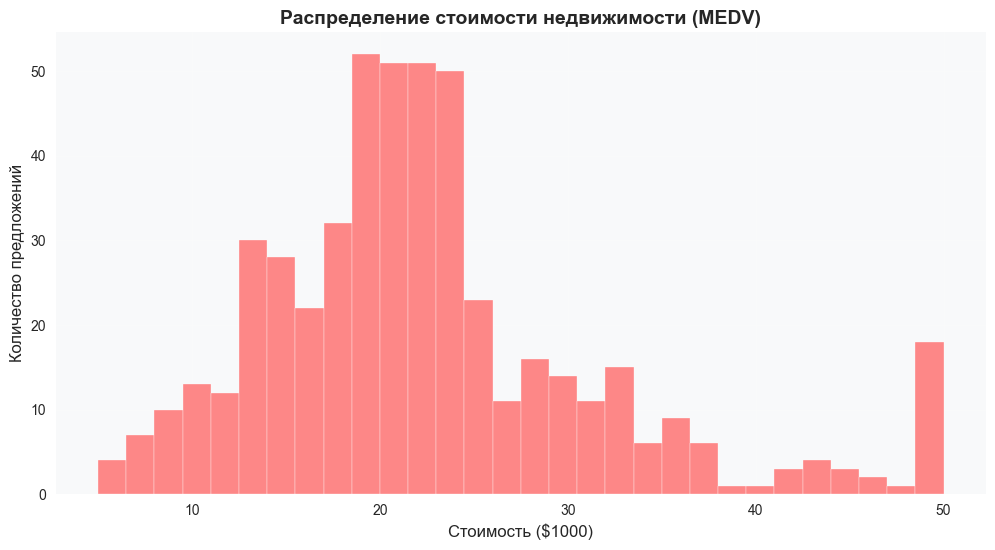


Статистика по целевой переменной (MEDV):
Средняя цена: $22.53 тыс.
Медианная цена: $21.20 тыс.
Минимальная цена: $5.00 тыс.
Максимальная цена: $50.00 тыс.

3. Гиперпараметры модели:
criterion: squared_error
max_depth: 4
min_samples_split: 20
min_samples_leaf: 10
random_state: 42

Качество модели на тестовой выборке:
Mean Squared Error (MSE): 19.93
R² Score: 0.7282

4. Визуализация дерева решений


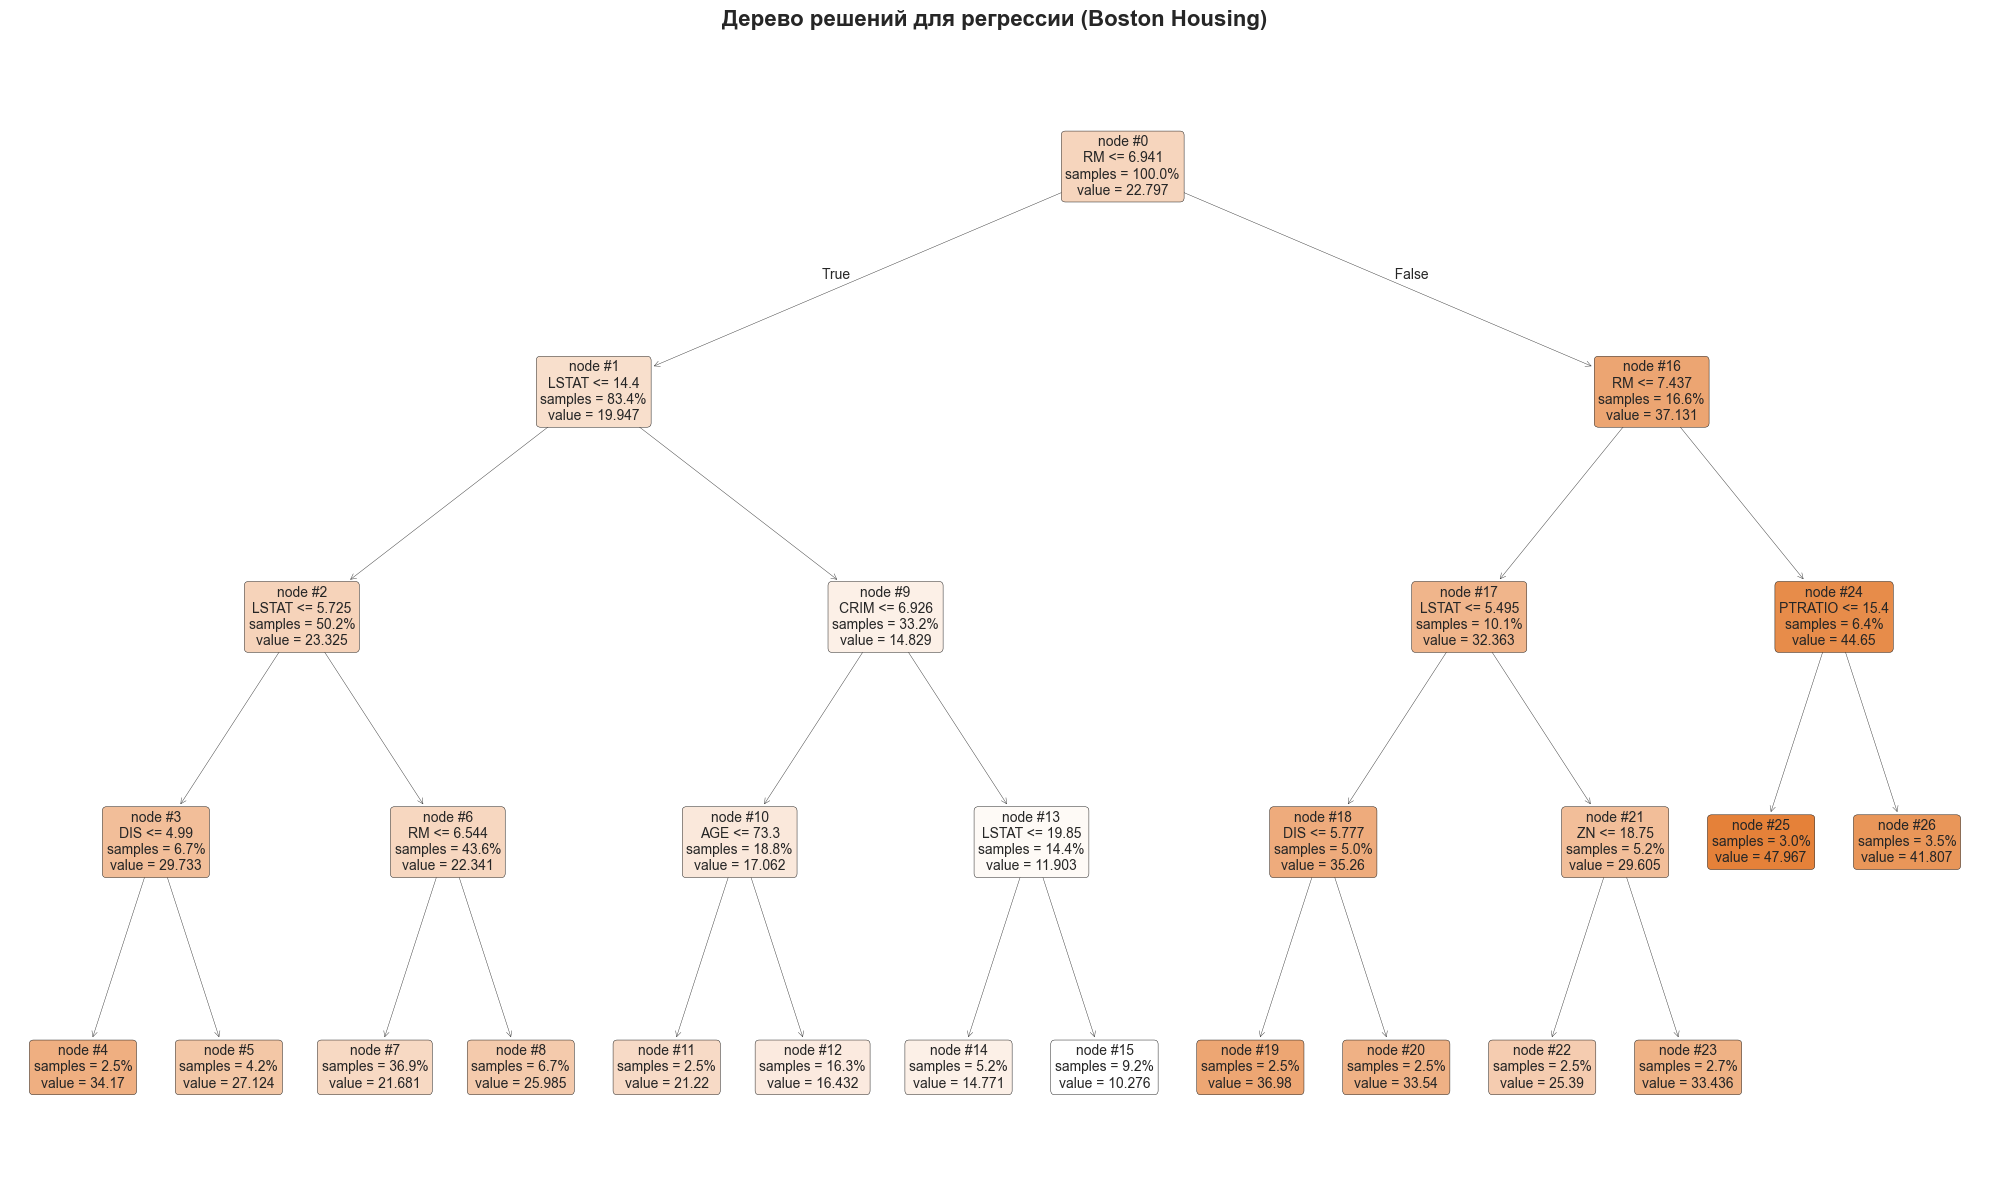


Важность признаков:
    feature  importance
5        RM    0.665092
12    LSTAT    0.265044
0      CRIM    0.030117
7       DIS    0.012792
1        ZN    0.011669
10  PTRATIO    0.008435
6       AGE    0.006850
2     INDUS    0.000000
3      CHAS    0.000000
4       NOX    0.000000
8       RAD    0.000000
9       TAX    0.000000
11        B    0.000000


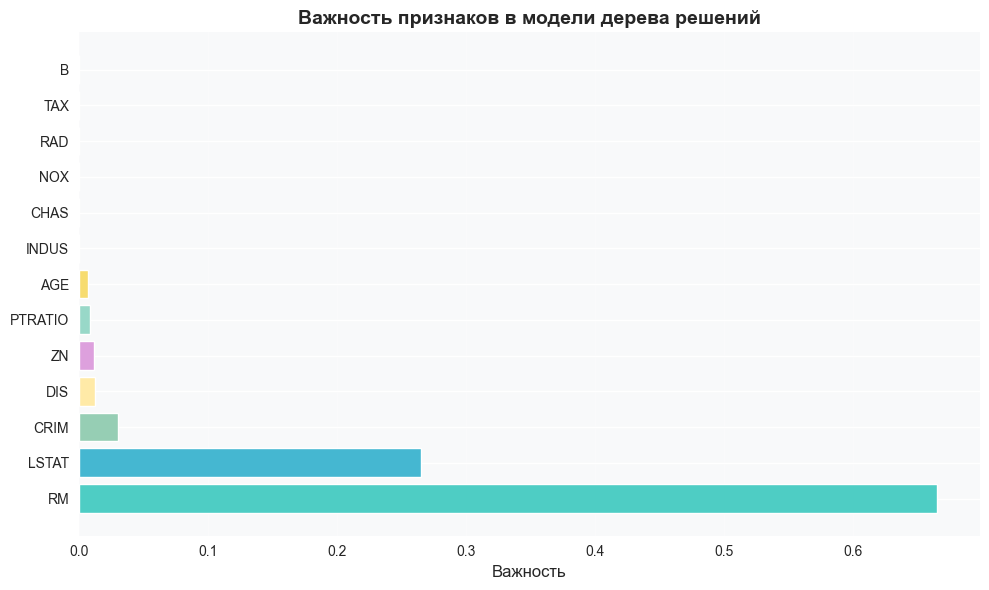


5. Применение для контрольного объекта
Характеристики контрольного объекта:
CRIM: 0.1
ZN: 18.0
INDUS: 2.5
CHAS: 0
NOX: 0.5
RM: 6.5
AGE: 65.0
DIS: 4.0
RAD: 5
TAX: 300
PTRATIO: 19
B: 390
LSTAT: 5.0

Предсказанная стоимость: $34.17 тыс.
Средняя цена в датасете: $22.53 тыс.
Отклонение от средней: $11.64 тыс.


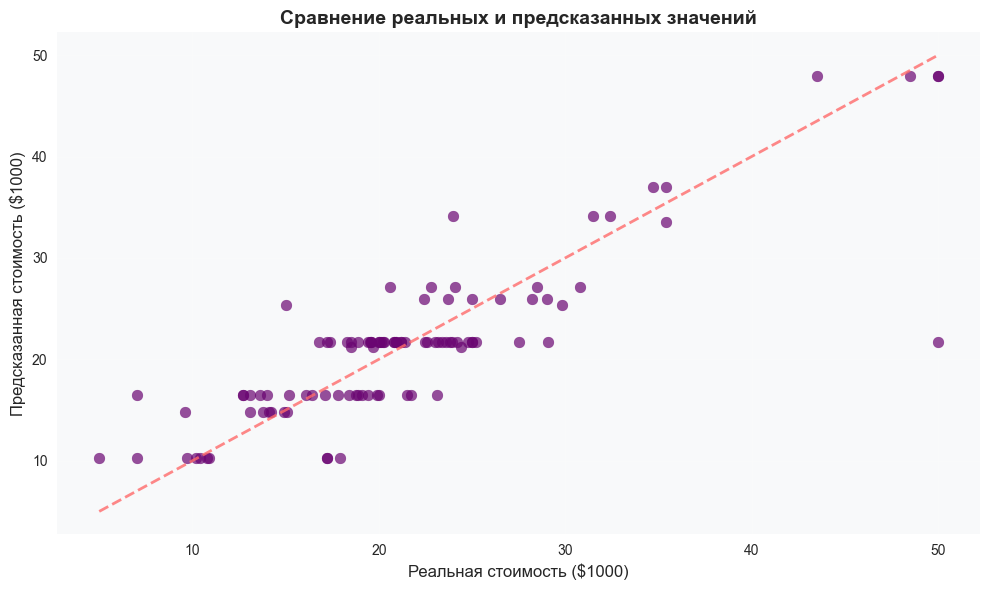

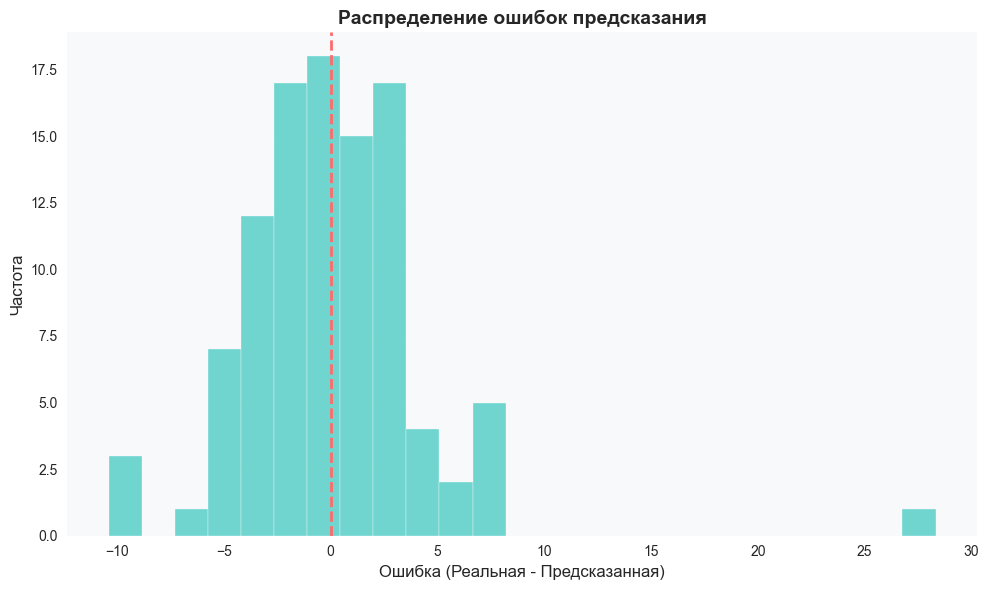


Средняя абсолютная ошибка: $2.98 тыс.
Максимальная ошибка: $28.32 тыс.


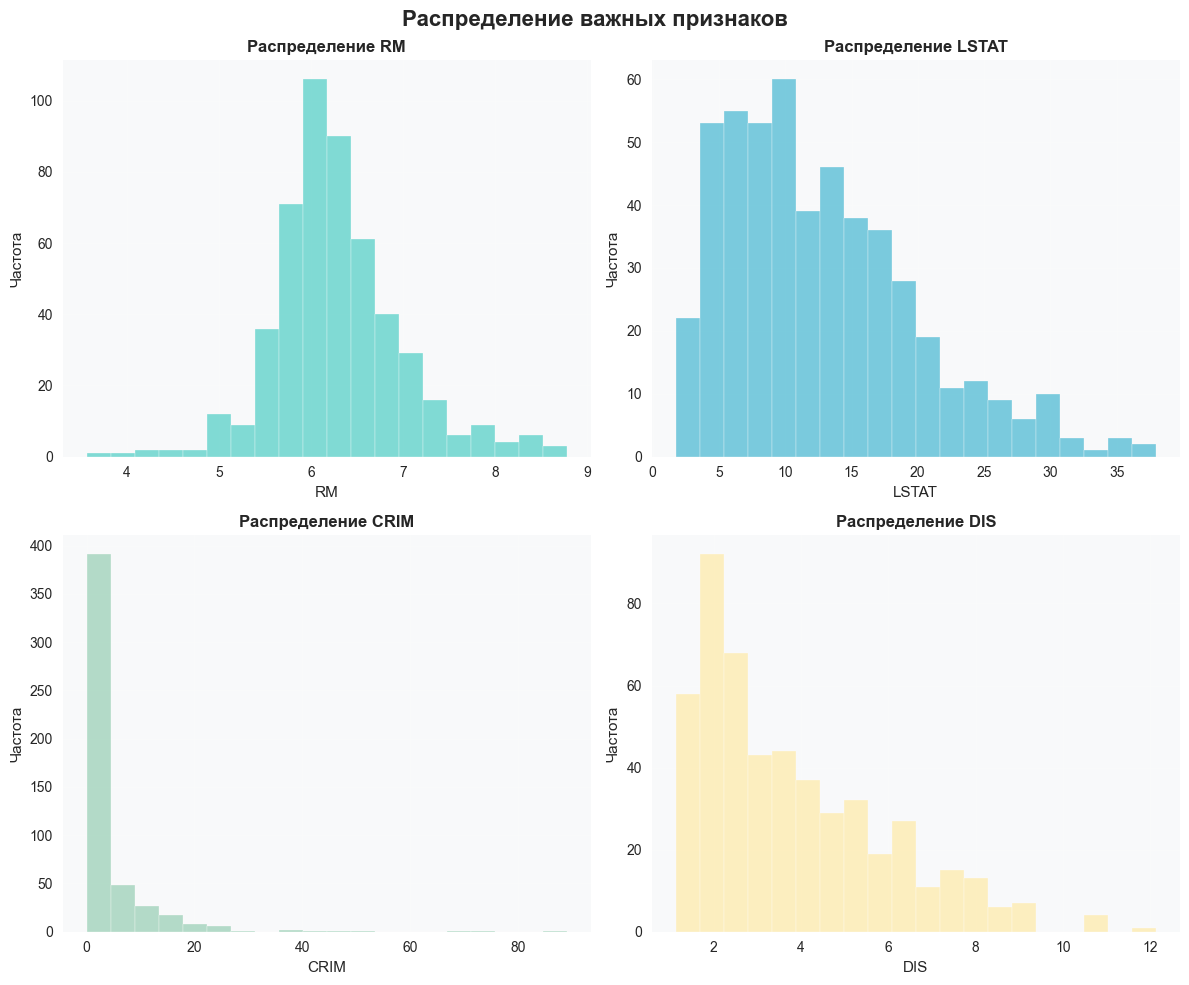

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

# Настройка стиля для всех графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Загрузка данных из CSV файла 
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
target_name = 'MEDV'

# Загрузка данных 
data = pd.read_csv('housing.csv', delim_whitespace=True, header=None)
data.columns = feature_names + [target_name]

# 1. Фрагмент исходного набора данных
print("1. Фрагмент исходного набора данных:")
print(f"Размерность данных: {data.shape}")
print(data.head(10))

# 2. Гистограмма распределения стоимости недвижимости
print("\n2. Гистограмма распределения стоимости недвижимости")
plt.figure(figsize=(12, 6))
plt.hist(data[target_name], bins=30, edgecolor='white', alpha=0.8, color='#FF6B6B')
plt.title('Распределение стоимости недвижимости (MEDV)', fontsize=14, fontweight='bold')
plt.xlabel('Стоимость ($1000)', fontsize=12)
plt.ylabel('Количество предложений', fontsize=12)
plt.grid(alpha=0.2)
plt.gca().set_facecolor('#F8F9FA')
plt.show()

# Дополнительная статистика
print(f"\nСтатистика по целевой переменной (MEDV):")
print(f"Средняя цена: ${data[target_name].mean():.2f} тыс.")
print(f"Медианная цена: ${data[target_name].median():.2f} тыс.")
print(f"Минимальная цена: ${data[target_name].min():.2f} тыс.")
print(f"Максимальная цена: ${data[target_name].max():.2f} тыс.")

# Разделение данных на обучающую и тестовую выборки
X = data[feature_names]
y = data[target_name]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Гиперпараметры модели
hyperparameters = {
    'criterion': 'squared_error',
    'max_depth': 4,
    'min_samples_split': 20,
    'min_samples_leaf': 10,
    'random_state': 42
}

print("\n3. Гиперпараметры модели:")
for param, value in hyperparameters.items():
    print(f"{param}: {value}")

# Создание и обучение модели
model = DecisionTreeRegressor(**hyperparameters)
model.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred = model.predict(X_test)

# Оценка качества модели
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nКачество модели на тестовой выборке:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

# 4. Визуализация построенного дерева с кастомными цветами
print("\n4. Визуализация дерева решений")
plt.figure(figsize=(20, 12))
plot_tree(model, 
          feature_names=feature_names, 
          filled=True, 
          rounded=True, 
          fontsize=10,
          proportion=True,
          impurity=False,
          node_ids=True,
          class_names=None)
plt.title('Дерево решений для регрессии (Boston Housing)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nВажность признаков:")
print(feature_importance)

# Визуализация важности признаков с новыми цветами
plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['feature'], feature_importance['importance'], 
                color=['#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8', '#F7DC6F'],
                edgecolor='white', linewidth=1)
plt.title('Важность признаков в модели дерева решений', fontsize=14, fontweight='bold')
plt.xlabel('Важность', fontsize=12)
plt.gca().set_facecolor('#F8F9FA')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Применение для контрольного объекта
print("\n5. Применение для контрольного объекта")

# Создаем тестовый объект
test_property = {
    'CRIM': 0.1,
    'ZN': 18.0,
    'INDUS': 2.5,
    'CHAS': 0,
    'NOX': 0.5,
    'RM': 6.5,
    'AGE': 65.0,
    'DIS': 4.0,
    'RAD': 5,
    'TAX': 300,
    'PTRATIO': 19,
    'B': 390,
    'LSTAT': 5.0
}

test_df = pd.DataFrame([test_property], columns=feature_names)
predicted_price = model.predict(test_df)[0]

print("Характеристики контрольного объекта:")
for feature, value in test_property.items():
    print(f"{feature}: {value}")

print(f"\nПредсказанная стоимость: ${predicted_price:.2f} тыс.")

# Сравнение со средней ценой в датасете
avg_price = data[target_name].mean()
print(f"Средняя цена в датасете: ${avg_price:.2f} тыс.")
print(f"Отклонение от средней: ${(predicted_price - avg_price):.2f} тыс.")

# Сравнение предсказаний с реальными значениями с новыми цветами
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='#6A0572', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='#FF6B6B', lw=2, alpha=0.8)
plt.xlabel('Реальная стоимость ($1000)', fontsize=12)
plt.ylabel('Предсказанная стоимость ($1000)', fontsize=12)
plt.title('Сравнение реальных и предсказанных значений', fontsize=14, fontweight='bold')
plt.grid(alpha=0.2)
plt.gca().set_facecolor('#F8F9FA')
plt.tight_layout()
plt.show()

# Анализ ошибок с новыми цветами
errors = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=25, edgecolor='white', alpha=0.8, color='#4ECDC4')
plt.title('Распределение ошибок предсказания', fontsize=14, fontweight='bold')
plt.xlabel('Ошибка (Реальная - Предсказанная)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.axvline(x=0, color='#FF6B6B', linestyle='--', linewidth=2)
plt.grid(alpha=0.2)
plt.gca().set_facecolor('#F8F9FA')
plt.tight_layout()
plt.show()

print(f"\nСредняя абсолютная ошибка: ${np.mean(np.abs(errors)):.2f} тыс.")
print(f"Максимальная ошибка: ${np.max(np.abs(errors)):.2f} тыс.")

# Дополнительная визуализация: распределение важных признаков
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Распределение важных признаков', fontsize=16, fontweight='bold')

# Топ-4 самых важных признака
top_features = feature_importance.head(4)['feature'].values

for i, feature in enumerate(top_features):
    ax = axes[i//2, i%2]
    ax.hist(data[feature], bins=20, alpha=0.7, color=['#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'][i], edgecolor='white')
    ax.set_title(f'Распределение {feature}', fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Частота')
    ax.grid(alpha=0.2)
    ax.set_facecolor('#F8F9FA')

plt.tight_layout()
plt.show()
